In [1]:
#%env JAX_PLATFORM=cpu
%env CUDA_VISIBLE_DEVICES=1
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
%env JAX_ENABLE_X64=True

import jax
import jax.numpy as jnp
import jax.random as jr

env: CUDA_VISIBLE_DEVICES=1
env: XLA_PYTHON_CLIENT_PREALLOCATE=false
env: JAX_ENABLE_X64=True


In [2]:
from systems import Cascade, faulty_actuators, faulty_sensors, as_healty, as_faulty
from observers import KalmanFilter
from controllers import MPC
from ppo import PPO
from simulator  import Simulator

In [3]:
T = 100
gamma = 0.9
sys = faulty_actuators(as_faulty(Cascade(x_dim=2, u_dim=2, y_dim=1)))
aug_sys = as_healty(sys)
ref_y = jnp.ones((T, sys.y_dim))
ref_u = jnp.zeros((T, sys.u_dim))
Jy = 1.0 * jnp.eye(sys.y_dim)
Ju = 0.0001 * jnp.eye(sys.u_dim)
Je = 0.1 * jnp.eye(sys.x_dim + sys.z_dim)

Q = 0.1 * jnp.eye(aug_sys.x_dim)
R = 0.1 * jnp.eye(aug_sys.y_dim)

mpc = MPC(sys=aug_sys, Jy=Jy, Ju=Ju, horizon=10, discount=gamma)
kf = KalmanFilter(sys=aug_sys, Q=Q, R=R)
ppo = PPO(x_dim=aug_sys.x_dim, u_dim=aug_sys.u_dim, discount=gamma)
sim = Simulator(sys, mpc, kf, ppo, Jy=Jy, Ju=Ju, Je=Je, ref_y=ref_y, ref_u=ref_u)

100%|██████████| 100/100 [00:00<00:00, 195.45it/s]


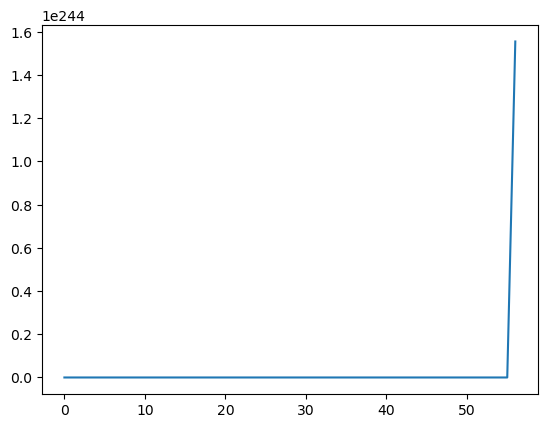

In [13]:
from tqdm import tqdm
import matplotlib.pyplot as plt


def trajectory(x0, ut):
    step = lambda x, u: aug_sys(x, u, rng=None)
    _, yt = jax.lax.scan(step, x0, ut)
    return yt
    
x0 = aug_sys.reset(rng=None).x
ut = jr.normal(jr.key(0), shape=(10, aug_sys.u_dim))


@jax.jit
def observability(x0, ut):
    C = jax.jacobian(lambda x:trajectory(x, ut))(x0)
    g = jnp.einsum('t y i,t y j -> i j', C, C)
    return jnp.linalg.det(g)

@jax.jit
def grad(u):
    loss = lambda u: 0.01*jnp.sum(u**2)-observability(x0, u)
    return jax.grad(loss)(u)

o = [observability(x0, ut)]
for _ in tqdm(range(100)):
    ut = ut - 0.1 * grad(ut)
    o.append(observability(x0, ut))

plt.plot(o)

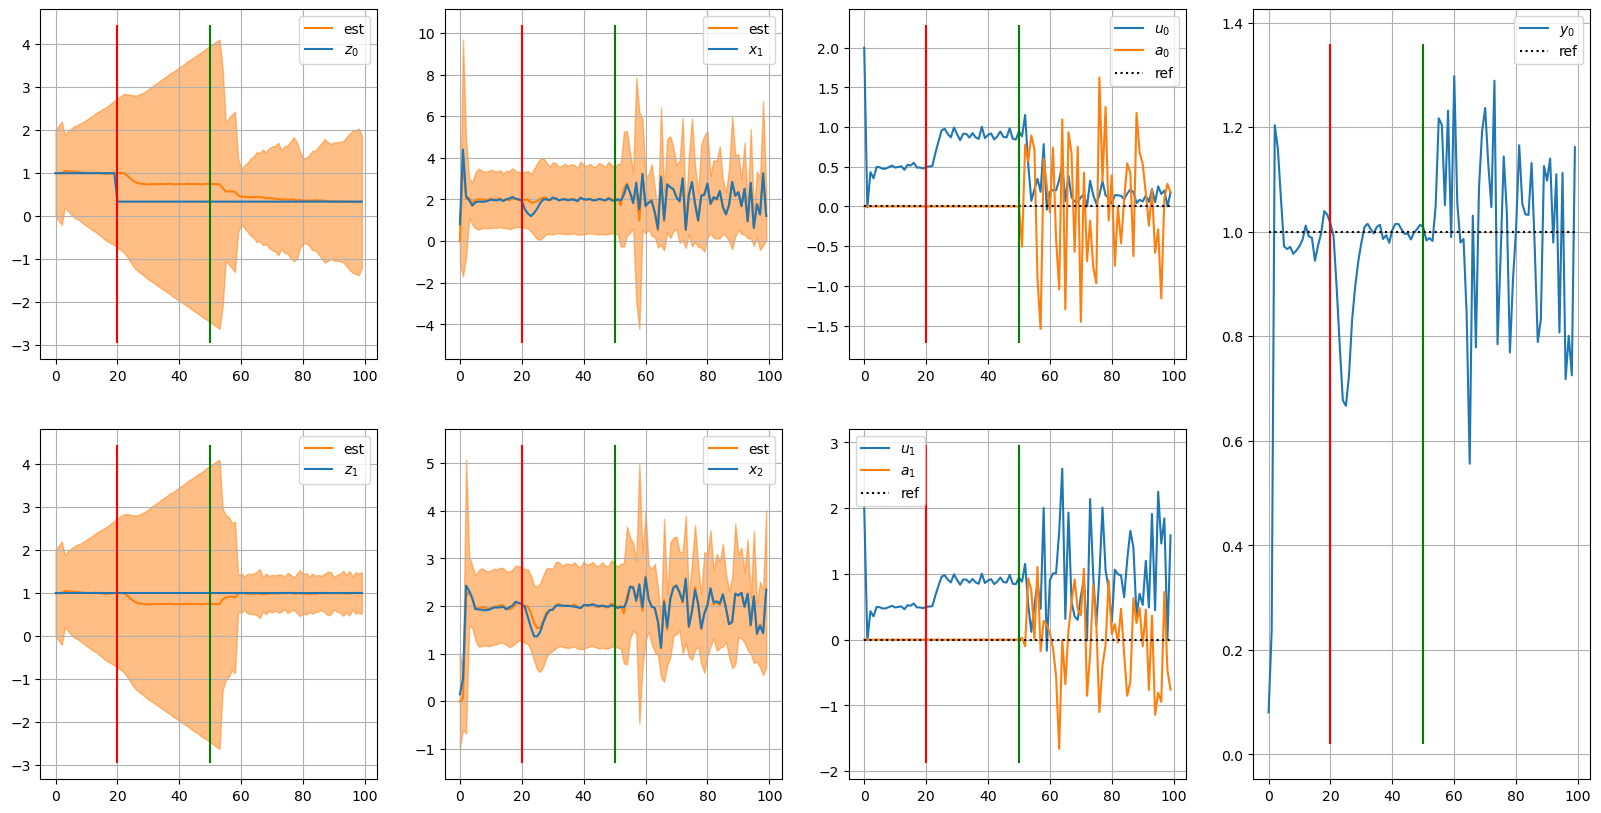

In [ ]:
for seed in range(1):
    _, states, out = sim.rollout(rng=jr.key(seed))
    sim.plot(states, out)

In [ ]:
sim, log_loss, log_rew = sim.optimize(500, batch=1024, lr=0.001)

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [02:45<00:00,  3.02it/s, V=-4.804073082878797, loss=0.231, rew=-0.7550096339394918] 


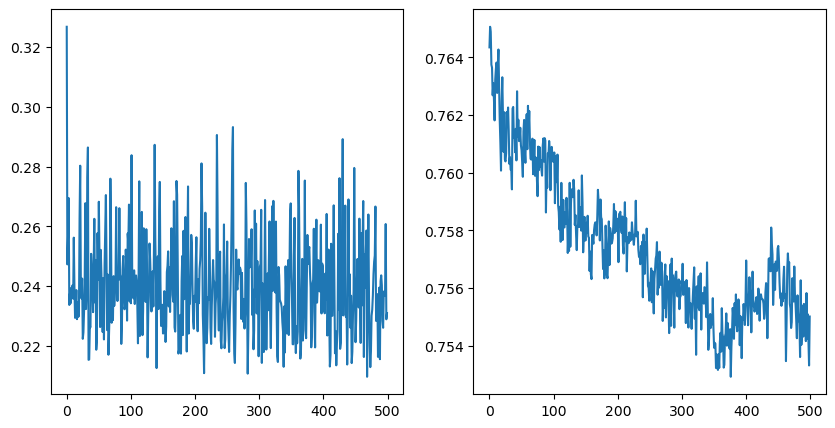

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.plot(log_loss)
plt.subplot(122)
plt.plot(-log_rew)

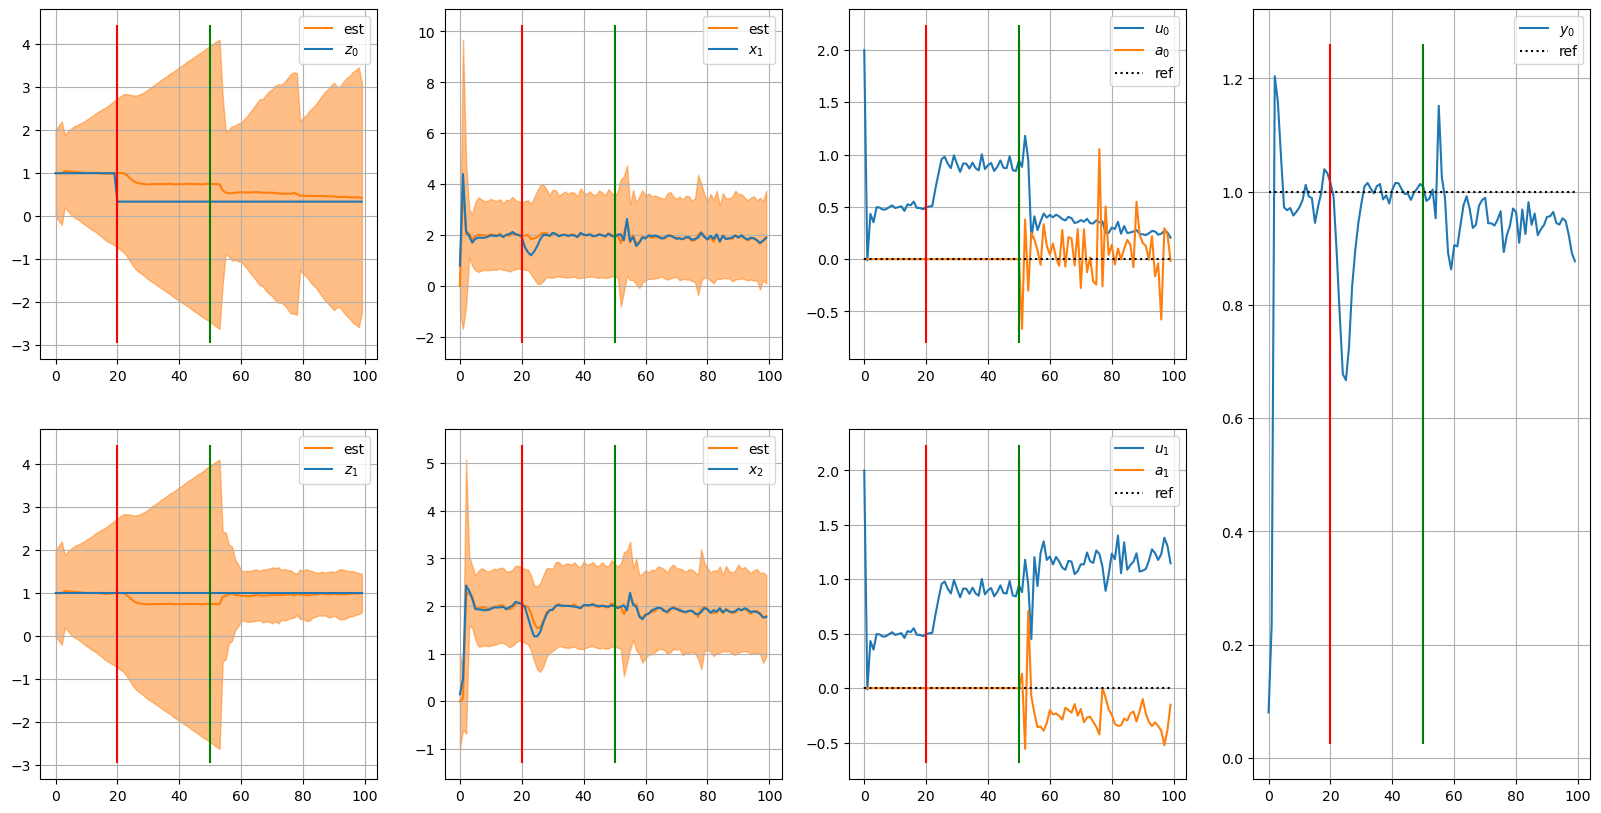

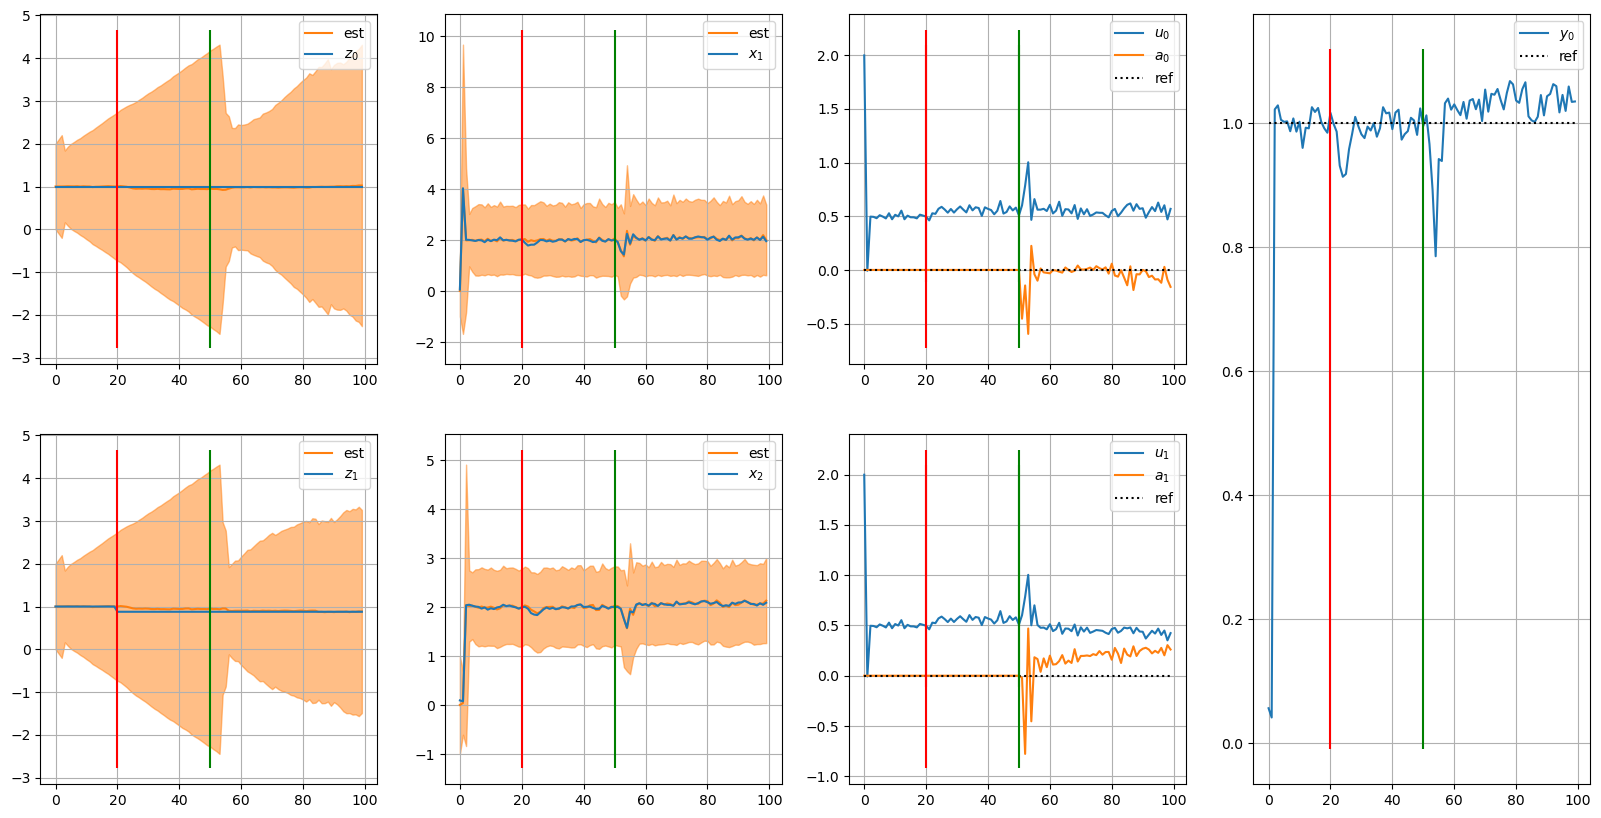

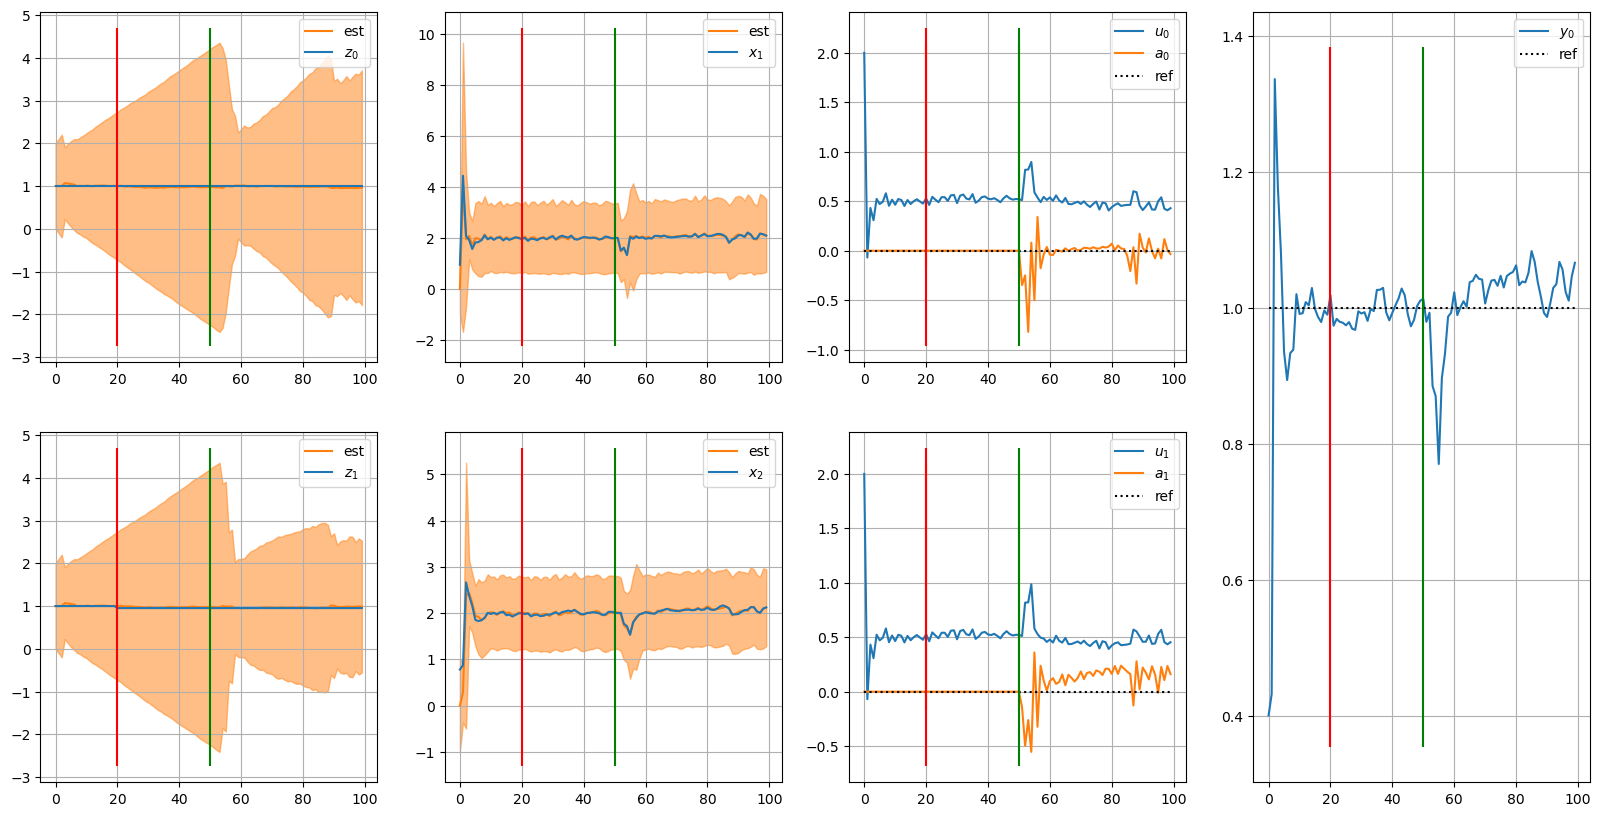

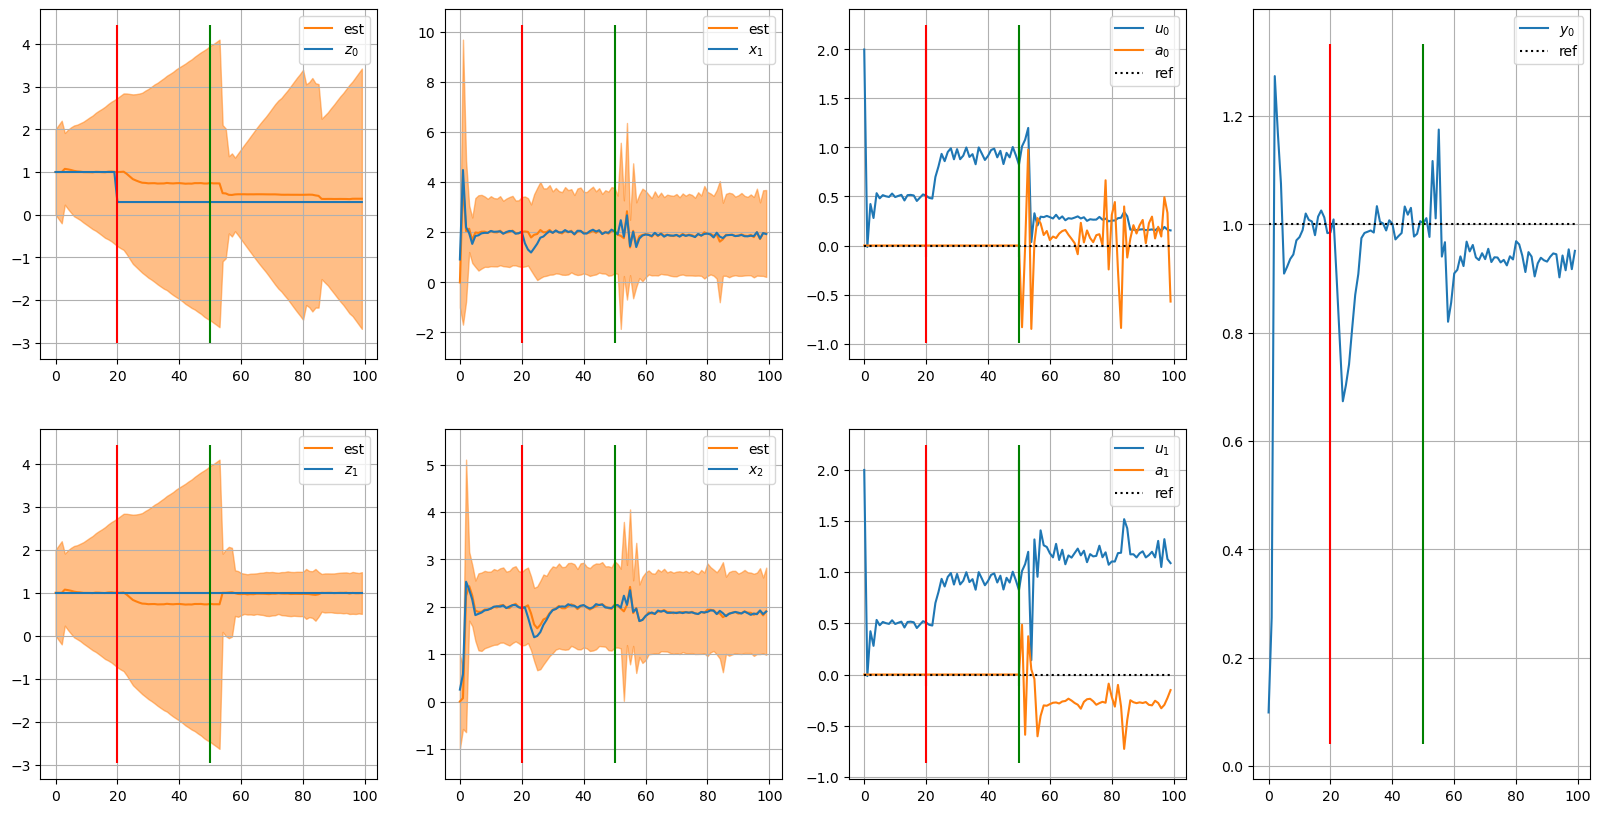

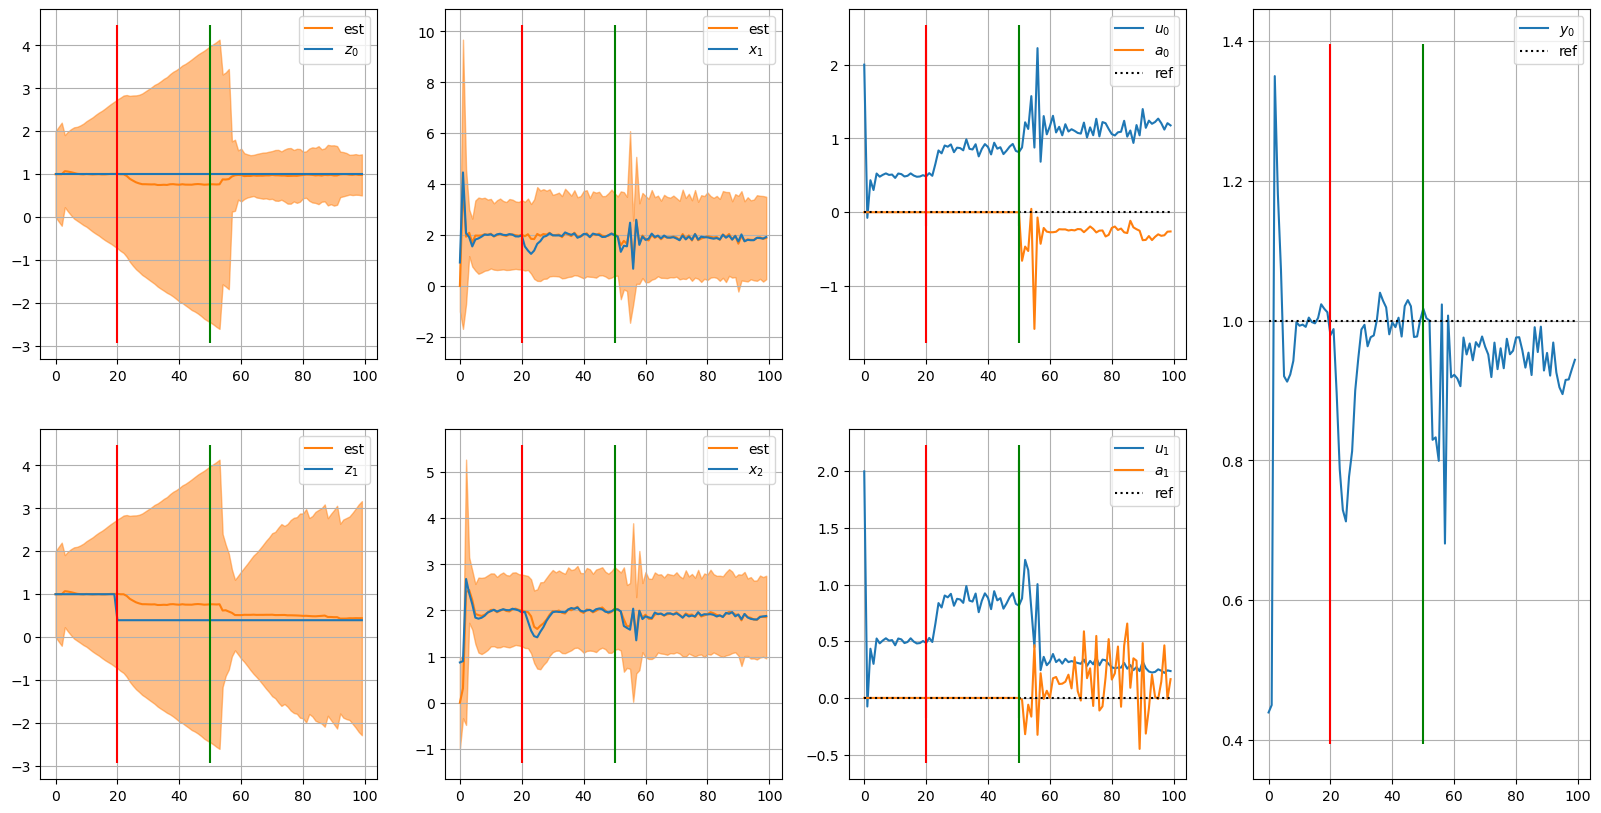

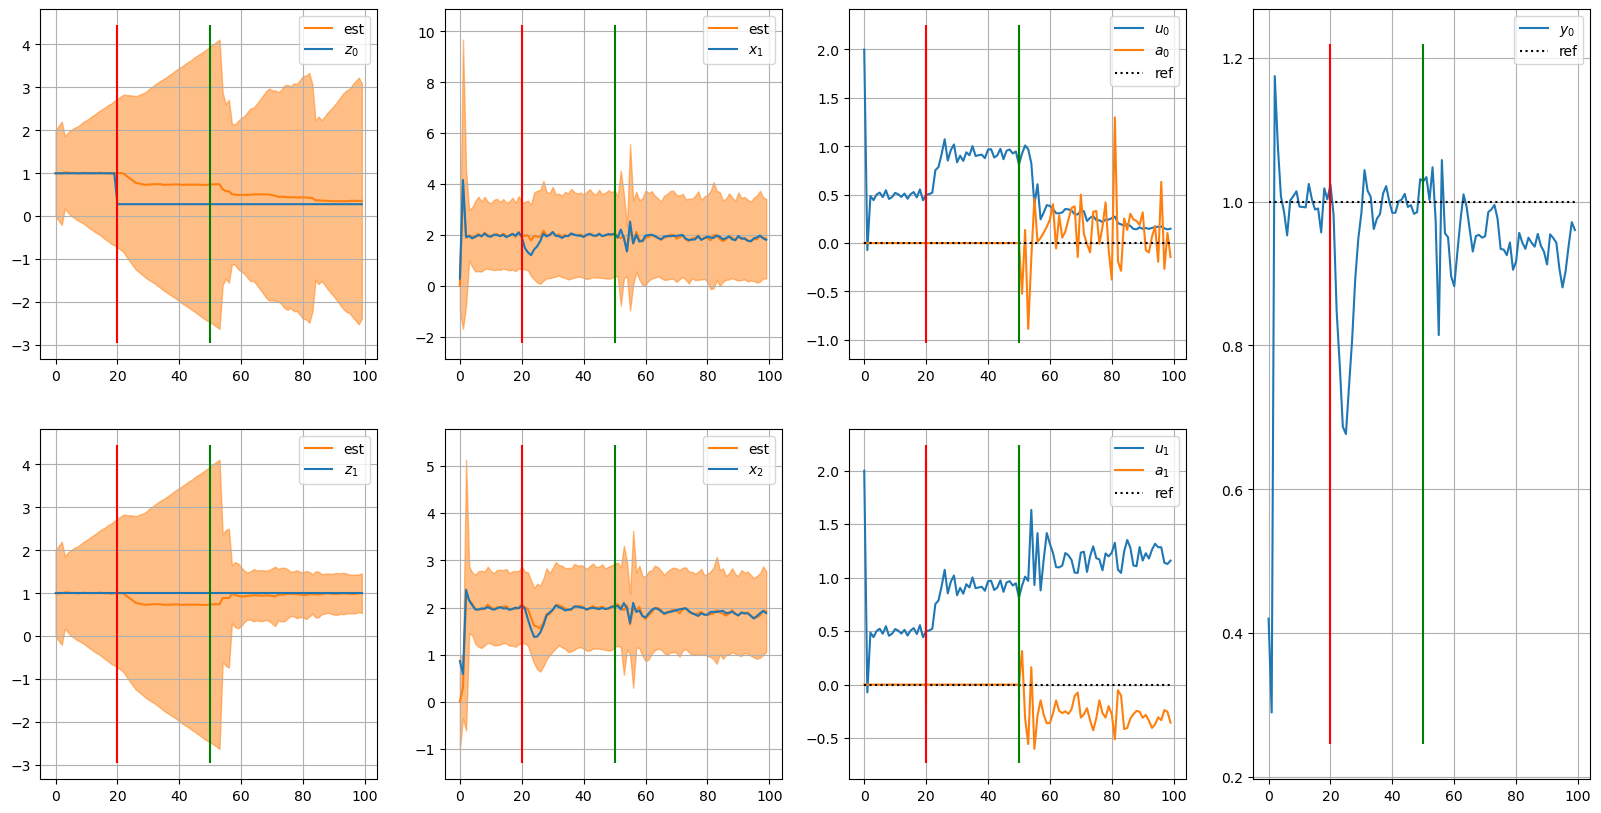

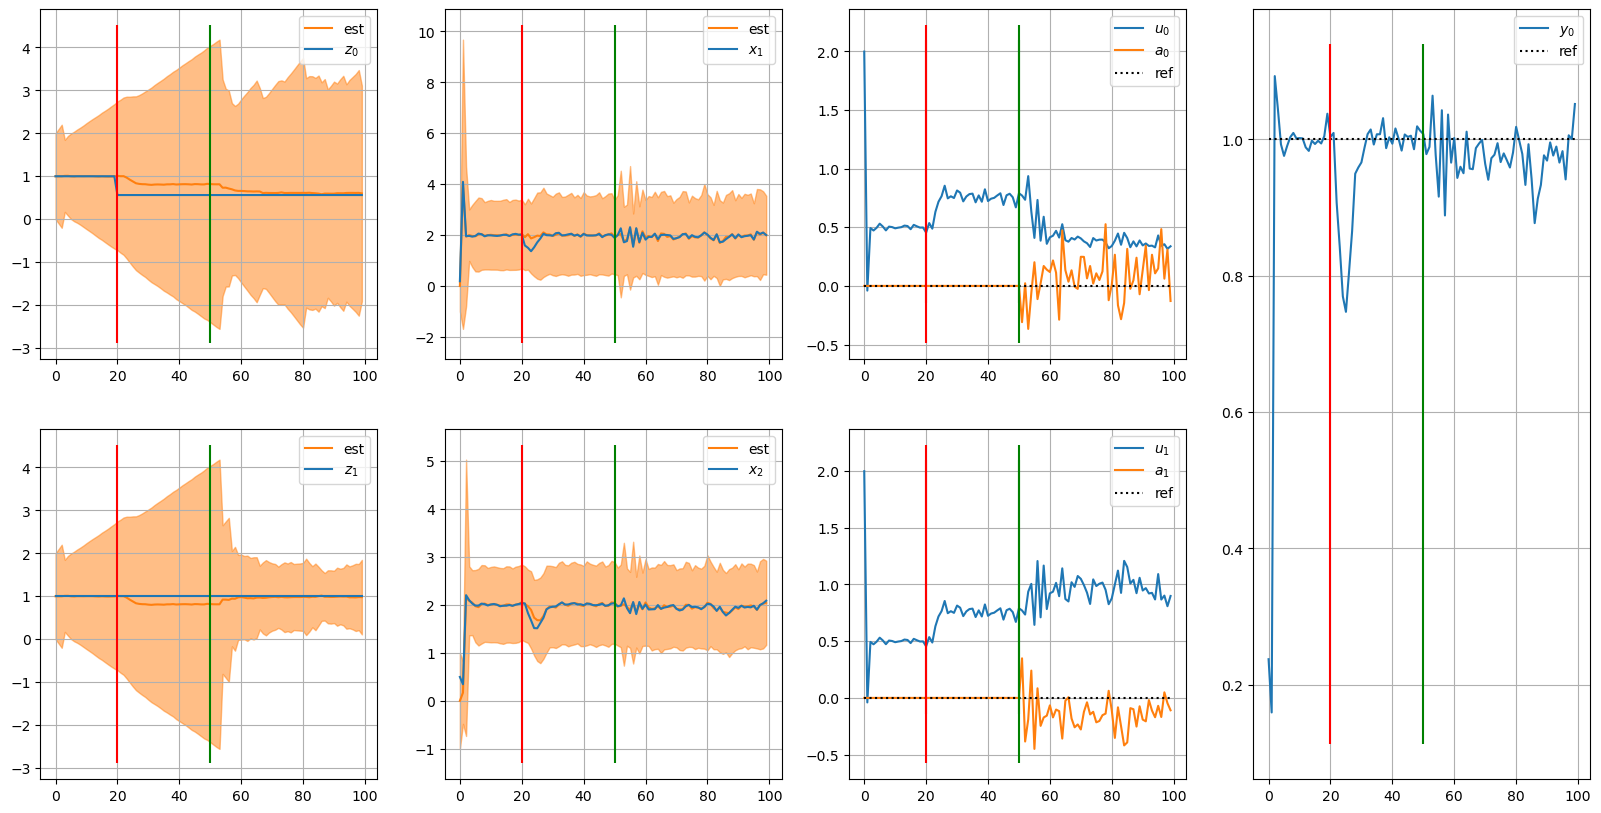

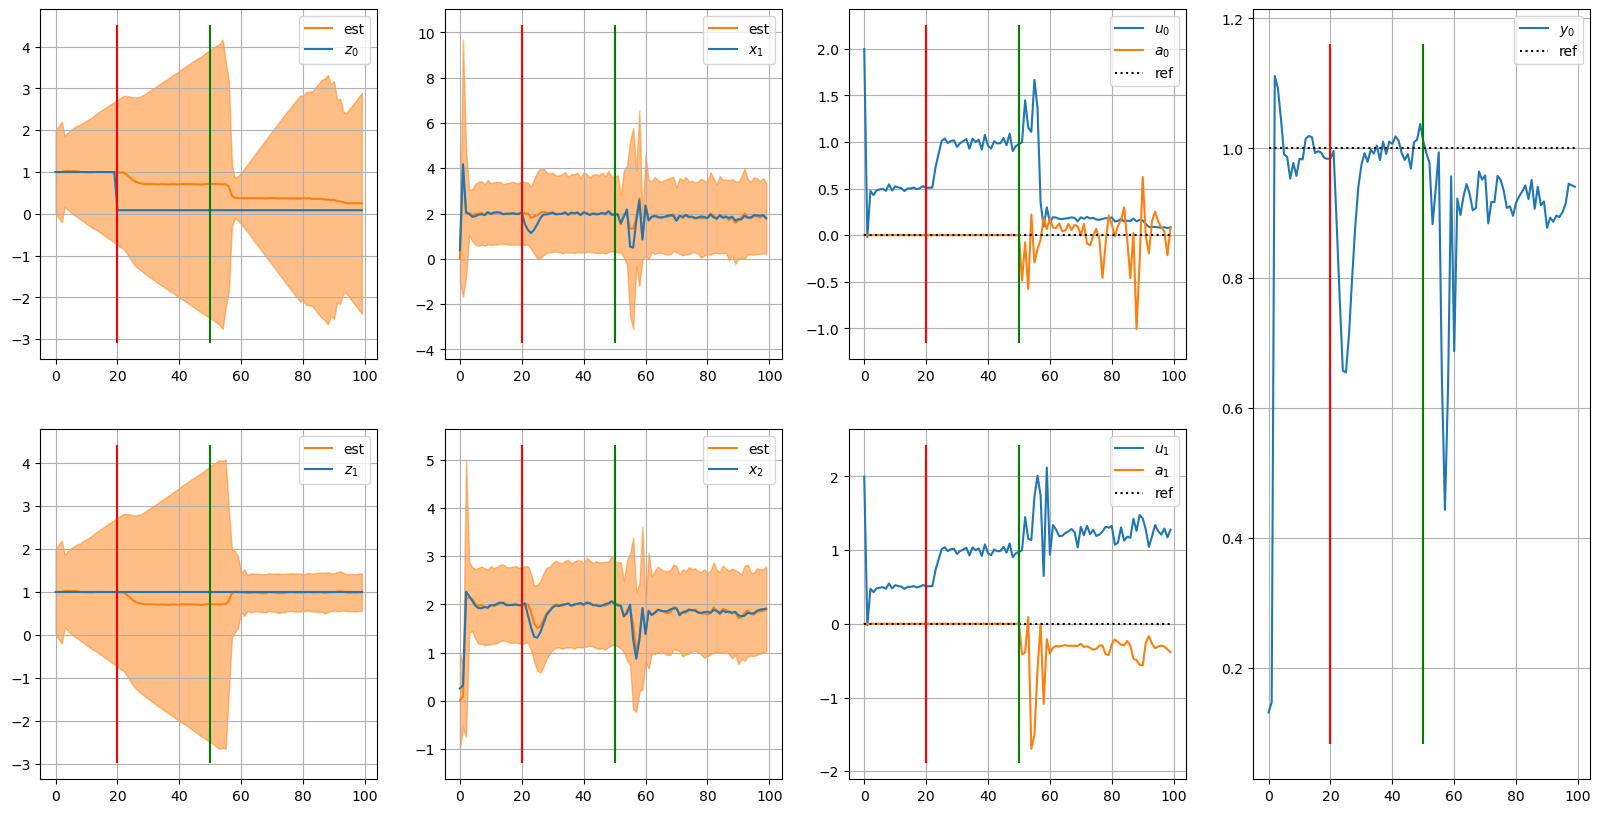

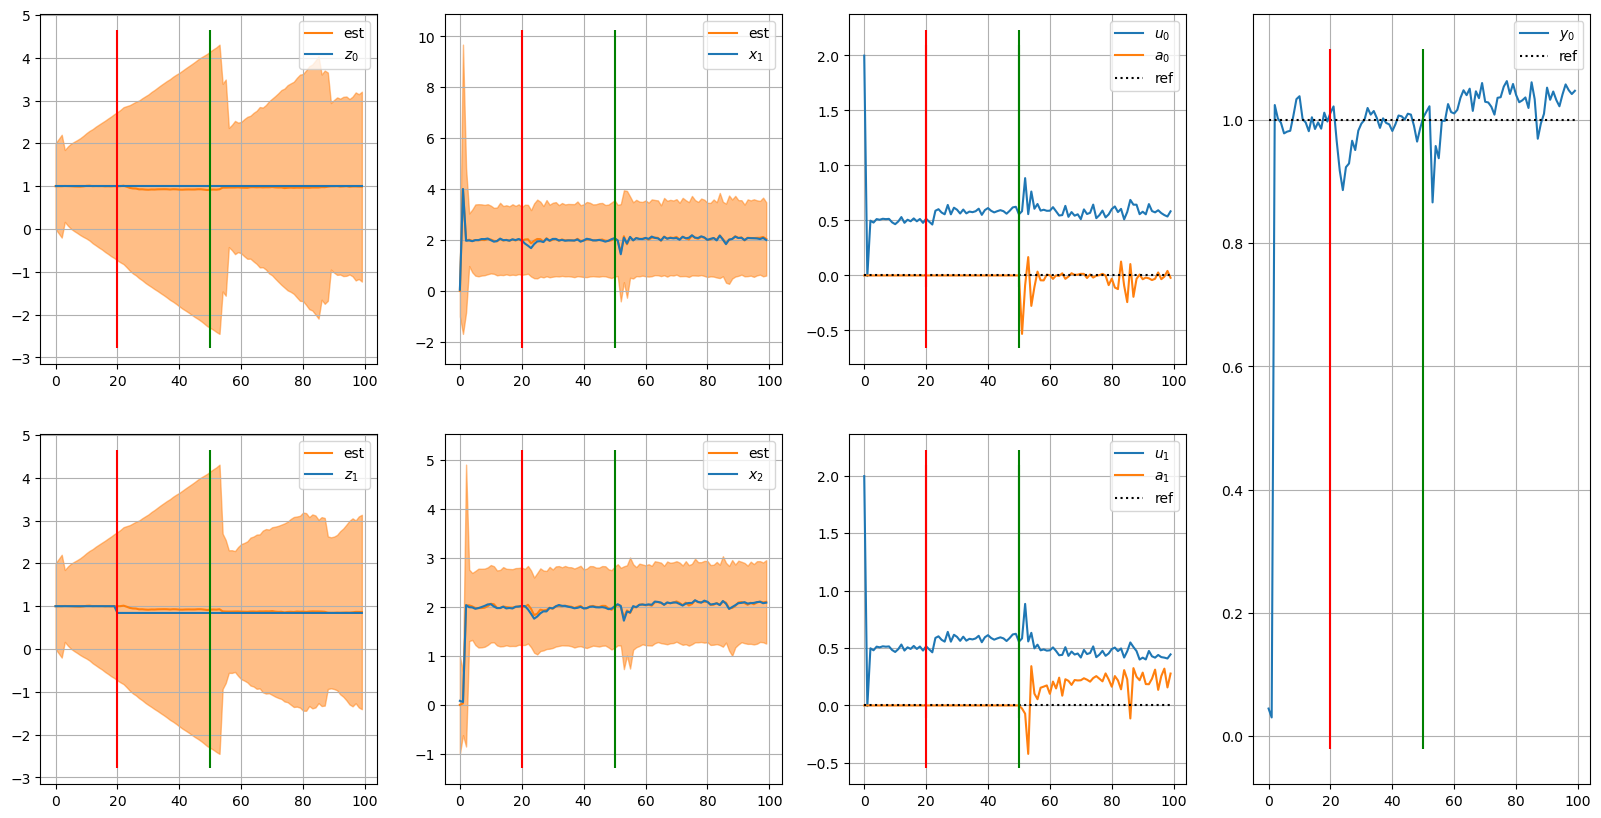

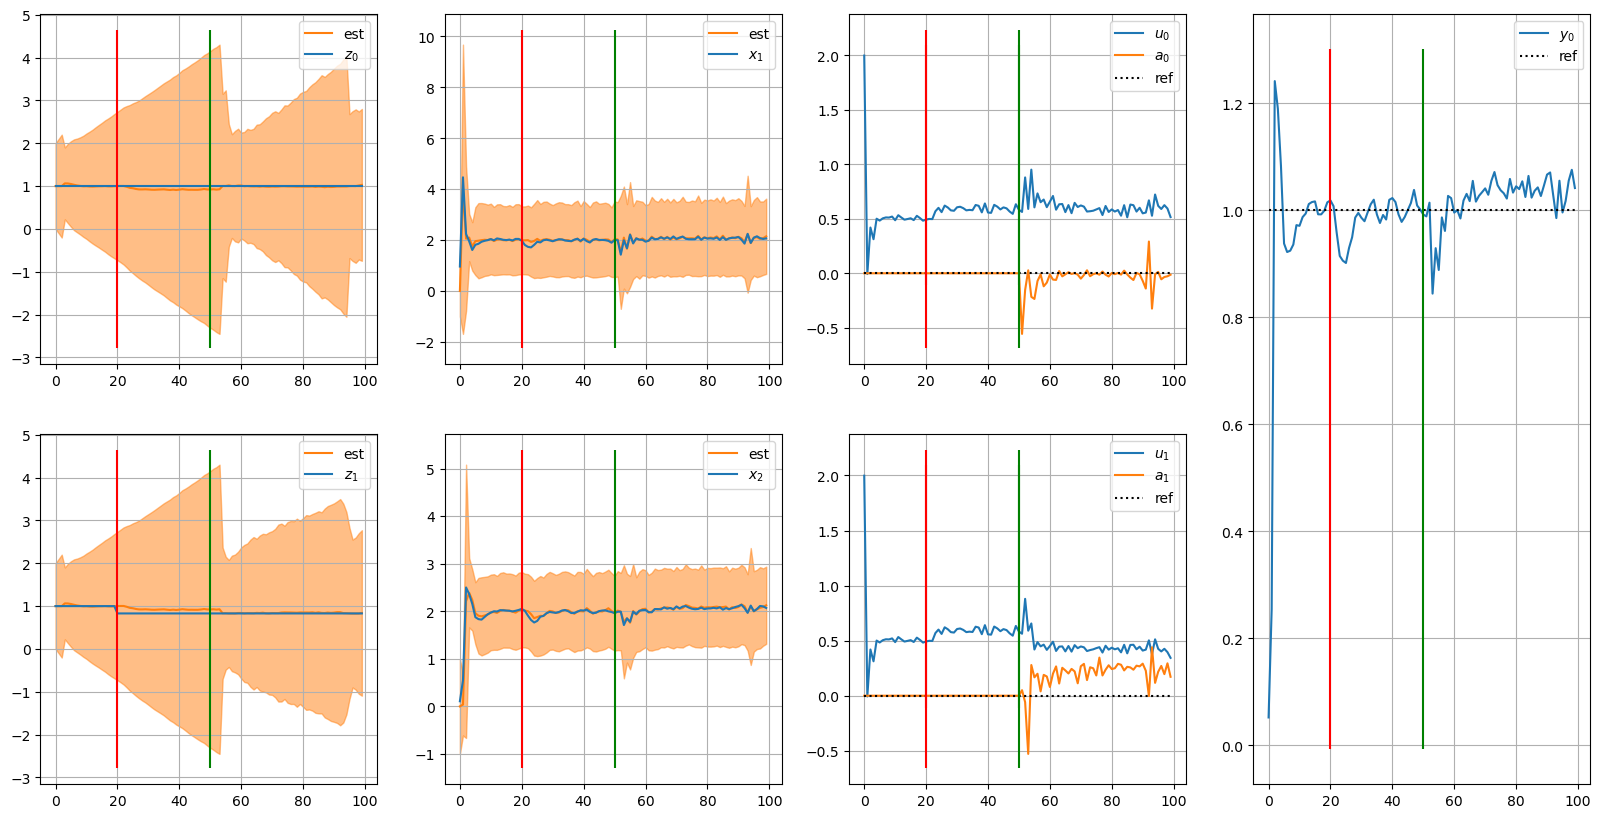

In [ ]:
for seed in range(10):
    _, states, out = sim.rollout(rng=jr.key(seed))
    sim.plot(states, out)